# Analyse Exploratoire

## Import des ibraries

In [1]:
import pandas as pd
import os
import glob
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

## Chargement du dataset SILVER

In [2]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"

try:
    path_dataset = next(repertoire_data_processed.glob("02_dataset_silver.csv"))
    print(f"Fichier trouvé : {path_dataset}")
    
    # Lecture
    df = pd.read_csv(path_dataset)
except StopIteration:
    print("Erreur : Le fichier '02_dataset_silver.csv' est introuvable dans le dossier.")

Fichier trouvé : /home/julien/Repos/fil_rouge-etude_chomage_france/data/processed/02_dataset_silver.csv


In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
# Apercu
df.head(150)

,date,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,...,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,indicateur_climat_affaires_diff_lag,taux_euribor_3m_diff,mro_diff,taux_change_eur_dollar_var,is_covid
0,2000-01-01,9.1,8.0,10.3,19.0,8.4,6.1,4018600.0,1774200.0,2244400.0,...,1.723014,1.345448,0.389039,-4.1,-4.3,5.9,0.112500,0.416667,-0.050268,0
1,2000-04-01,8.7,7.6,9.9,18.0,8.0,5.8,3890000.0,1701100.0,2188900.0,...,1.754474,1.977185,3.053740,6.0,0.3,-4.3,0.720700,0.666667,-0.038337,0
2,2000-07-01,8.4,7.2,9.6,17.4,7.8,5.5,3807900.0,1659300.0,2148600.0,...,1.901287,1.861366,-4.481288,-1.1,1.4,0.3,0.474600,0.333333,-0.036859,0
3,2000-10-01,8.0,6.9,9.4,16.9,7.5,5.2,3690300.0,1601400.0,2088900.0,...,1.492307,1.966656,4.852425,1.0,-3.9,1.4,0.286567,0.000000,-0.018875,0
4,2001-01-01,7.8,6.6,9.2,16.8,7.3,4.9,3609400.0,1565300.0,2044100.0,...,1.376954,1.819251,-1.117994,-1.4,-1.1,-3.9,-0.279133,0.000000,0.036620,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,2024-07-01,7.4,7.6,7.1,19.7,6.6,4.7,5412400.0,2637700.0,2774700.0,...,-0.300908,-0.160190,5.413804,-1.5,-2.2,-0.8,-0.252833,-0.366667,0.025902,0
99,2024-10-01,7.3,7.4,7.1,18.7,6.6,4.7,5491700.0,2678900.0,2812800.0,...,-0.552588,-0.381298,-6.641302,-2.1,-2.4,-2.2,-0.558867,-0.733333,-0.038597,0
100,2025-01-01,7.5,7.5,7.4,19.2,6.8,4.8,5738000.0,2811000.0,2927000.0,...,-0.384802,-0.391827,2.398082,-0.1,1.6,-2.4,-0.439667,-0.416667,-0.006723,0
101,2025-04-01,7.6,7.7,7.4,19.1,6.9,4.8,5612100.0,2749800.0,2862300.0,...,-0.447721,-0.191777,-2.470248,1.9,-0.6,1.6,-0.449133,-0.583333,0.088965,0


## Re-vérification des caractéristiques du dataframe

In [5]:
# Shape
print(f"Nombre de colonnes : {len(df.columns)}")
print(f"Nombre de lignes : {len(df)}")

Nombre de colonnes : 59
Nombre de lignes : 103


Quelles sont les variables catégorielles ? Les variables numériques ? 

In [6]:
# type de colonnes
df.dtypes

# UNIQUEMENT DES VARIABLES NUMERIQUES

date                                    datetime64[us]
taux_chomage_total_insee                       float64
taux_chomage_homme_insee                       float64
taux_chomage_femme_insee                       float64
taux_chomage_15_24_insee                       float64
taux_chomage_25_49_insee                       float64
taux_chomage_50_plus_insee                     float64
demandeur_total_abcd_total                     float64
demandeur_homme_abcd_total                     float64
demandeur_femme_abcd_total                     float64
demandeur_total_abcd_moins25                   float64
demandeur_total_abcd_2549                      float64
demandeur_total_abcd_plus50                    float64
demandeur_homme_abcd_moins25                   float64
demandeur_homme_abcd_2549                      float64
demandeur_homme_abcd_plus50                    float64
demandeur_femme_abcd_moins25                   float64
demandeur_femme_abcd_2549                      float64
demandeur_

In [7]:
df.iloc[:, 0:7].describe()

# Commentaire(s) :
### RAS

,date,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee
count,103,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,2012-09-30 13:02:54.757281,8.678641,8.480583,8.903883,21.717476,7.857282,5.615534
min,2000-01-01 00:00:00,7.100000,6.500000,6.800000,16.500000,6.300000,4.100000
25%,2006-05-16 12:00:00,7.800000,7.550000,8.050000,19.000000,7.200000,5.050000
50%,2012-10-01 00:00:00,8.800000,8.200000,9.200000,21.800000,7.900000,5.500000
75%,2019-02-15 00:00:00,9.300000,9.250000,9.700000,24.650000,8.400000,6.250000
max,2025-07-01 00:00:00,10.500000,11.000000,10.400000,27.900000,9.700000,7.200000
std,NaN,0.994066,1.180649,0.999796,3.199768,0.935425,0.767445


In [8]:
df.iloc[:, 8:19].describe()

# Commentaire(s) :
### RAS

,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,demandeur_total_abcd_2549,demandeur_total_abcd_plus50,demandeur_homme_abcd_moins25,demandeur_homme_abcd_2549,demandeur_homme_abcd_plus50,demandeur_femme_abcd_moins25,demandeur_femme_abcd_2549,demandeur_femme_abcd_plus50
count,1.030000e+02,1.030000e+02,103.000000,1.030000e+02,1.030000e+02,103.000000,1.030000e+02,103.000000,103.000000,1.030000e+02,103.000000
mean,2.285973e+06,2.475779e+06,716825.242718,3.021532e+06,1.023394e+06,357899.029126,1.441559e+06,486514.563107,358926.213592,1.579973e+06,536879.611650
std,4.965842e+05,4.445468e+05,79514.584577,4.654182e+05,4.233691e+05,49824.508685,2.622320e+05,201249.082038,31815.072150,2.114655e+05,222305.274279
min,1.499000e+06,1.746200e+06,550800.000000,2.186700e+06,5.057000e+05,257900.000000,1.007300e+06,230700.000000,292100.000000,1.179400e+06,274700.000000
25%,1.806800e+06,2.073700e+06,661750.000000,2.621100e+06,5.927000e+05,326050.000000,1.201200e+06,282250.000000,331300.000000,1.409200e+06,309250.000000
50%,2.400400e+06,2.482100e+06,722700.000000,3.085600e+06,9.912000e+05,362900.000000,1.517100e+06,475200.000000,360100.000000,1.573700e+06,516000.000000
75%,2.767350e+06,2.885750e+06,782650.000000,3.489650e+06,1.486150e+06,394350.000000,1.687700e+06,704700.000000,386200.000000,1.776050e+06,779900.000000
max,2.968900e+06,3.138300e+06,866800.000000,3.710700e+06,1.597700e+06,453800.000000,1.805600e+06,753800.000000,413000.000000,1.905100e+06,843900.000000


In [9]:
df.iloc[:, 20:33].describe()

# Commentaire(s) :
### RAS

,pib,ict,nb_interimaires,taux_euribor_3m,mro,taux_change_eur_dollar,ipc,isj,ipc_energie_only,taux_chomage_ocde,nb_defaillances_entreprise,nb_offres_france_travail,indicateur_confiance_menage
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,1.030000e+02,103.000000
mean,572790.475728,87.980583,661273.427517,1.622106,2.066505,1.188039,1.690291,1.409709,4.062460,8.788673,13158.330097,8.054718e+05,96.474016
std,48875.755933,12.852611,89845.599252,1.783065,1.891008,0.155578,1.273935,1.091616,8.126612,0.967698,2906.614753,1.201445e+05,9.952683
min,480413.000000,64.000000,477838.210451,-0.566400,0.000000,0.861200,-0.433333,-0.066667,-16.100000,7.100000,5434.000000,4.132000e+05,79.867693
25%,541058.000000,78.150000,593762.607550,-0.137617,0.041667,1.085500,0.983333,0.733333,-0.900000,8.066667,11564.000000,7.196500e+05,88.529963
50%,570781.000000,90.100000,640411.444797,1.411633,1.250000,1.181200,1.633333,1.233333,3.400000,8.833333,13290.000000,8.046000e+05,96.098153
75%,610386.500000,97.500000,730857.542042,3.288900,4.250000,1.307150,2.083333,1.700000,10.500000,9.433333,15234.500000,8.795000e+05,101.724454
max,661062.000000,112.800000,821378.102512,5.024167,4.500000,1.560400,6.100000,5.833333,29.133333,10.466667,18612.000000,1.069100e+06,123.650611


In [10]:
df.iloc[:, 34:].describe()

# Commentaire(s) :
### Problème précédent avec ipc_yoy qui faisait une différence en % et générait une valeur "infinie" pour le 2ème trimestre 2017 
### --> utilisation de la fonction .diff() pour obtenir une différence en point (absolue).

,indicateur_climat_emploi,indicateur_retournement_conjoncturel,population_active_var,nb_offres_france_travail_var,nb_defaillances_entreprise_var,nb_interimaires_var,pib_logdiff,pib_logdiff_lag,ipc_yoy,ipc_energie_only_yoy,...,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,indicateur_climat_affaires_diff_lag,taux_euribor_3m_diff,mro_diff,taux_change_eur_dollar_var,is_covid
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,...,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,101.481553,0.270583,0.001513,0.009216,0.019266,0.003579,0.003193,0.003278,0.020518,-0.186278,...,0.067040,0.143207,-0.308233,-0.229126,-0.243689,-0.185437,-0.013769,-0.006634,0.002054,0.048544
std,9.473831,0.764716,0.001806,0.128447,0.194379,0.059631,0.020633,0.020659,1.404171,11.797987,...,0.937755,0.997494,4.140644,5.491895,4.605020,4.644634,0.380054,0.310556,0.039885,0.215963
min,68.400000,-1.000000,-0.001736,-0.392353,-0.450831,-0.382981,-0.130333,-0.130333,-3.700000,-31.533333,...,-3.268628,-3.339930,-10.631357,-29.200000,-16.200000,-16.200000,-2.202967,-1.333333,-0.117539,0.000000
25%,95.650000,-0.600000,0.000277,-0.076769,-0.133362,-0.014512,0.000826,0.000826,-0.666667,-7.450000,...,-0.500155,-0.470794,-2.659974,-2.100000,-2.450000,-2.450000,-0.096517,0.000000,-0.023886,0.000000
50%,102.000000,0.800000,0.001542,0.009178,-0.036606,0.003300,0.003565,0.003565,-0.100000,-2.333333,...,0.181477,0.197794,-0.222131,-0.100000,-0.100000,0.000000,-0.004667,0.000000,0.001803,0.000000
75%,108.300000,0.900000,0.002160,0.086643,0.178711,0.031427,0.006418,0.006504,0.716667,6.983333,...,0.721539,0.861117,2.530401,2.150000,2.150000,2.200000,0.108667,0.000000,0.027262,0.000000
max,118.900000,1.000000,0.007419,0.564134,0.485646,0.224137,0.142772,0.142772,4.100000,28.066667,...,1.901287,1.977185,8.887986,23.200000,17.000000,17.000000,1.291400,1.166667,0.090650,1.000000


### Vérification de la colonne `ipc_yoy`

In [11]:
df["ipc_yoy"].unique()
# OK

array([ 1.24666667,  1.06666667,  1.36666667,  0.9       , -0.16666667,
        0.63333333, -0.13333333, -0.46666667,  0.86666667, -0.43333333,
        0.        ,  0.7       ,  0.2       ,  0.3       ,  0.03333333,
       -0.56666667,  0.46666667,  0.33333333, -0.06666667, -0.1       ,
       -0.66666667, -0.43333333, -0.4       ,  0.1       , -0.16666667,
       -0.36666667, -0.66666667, -0.73333333, -0.43333333,  1.        ,
        1.8       ,  2.1       ,  2.        , -2.3       , -3.53333333,
       -3.7       , -1.4       ,  1.83333333,  2.        ,  1.3       ,
        0.46666667,  0.46666667,  0.53333333,  0.76666667, -0.06666667,
       -0.13333333, -0.9       , -1.26666667, -1.2       , -1.        ,
       -0.86666667, -0.36666667, -0.16666667, -0.56666667, -0.96666667,
       -0.4       , -0.33333333, -0.2       ,  0.23333333, -0.23333333,
        0.2       ,  0.4       ,  1.23333333,  0.9       ,  0.6       ,
        0.66666667,  0.16666667,  0.96666667,  1.4       ,  0.73

## Vérification des valeurs manquantes

In [12]:
df.isna().any()

date                                    False
taux_chomage_total_insee                False
taux_chomage_homme_insee                False
taux_chomage_femme_insee                False
taux_chomage_15_24_insee                False
taux_chomage_25_49_insee                False
taux_chomage_50_plus_insee              False
demandeur_total_abcd_total              False
demandeur_homme_abcd_total              False
demandeur_femme_abcd_total              False
demandeur_total_abcd_moins25            False
demandeur_total_abcd_2549               False
demandeur_total_abcd_plus50             False
demandeur_homme_abcd_moins25            False
demandeur_homme_abcd_2549               False
demandeur_homme_abcd_plus50             False
demandeur_femme_abcd_moins25            False
demandeur_femme_abcd_2549               False
demandeur_femme_abcd_plus50             False
population_active                       False
pib                                     False
ict                               

# EXPLORATION DES DONNÉES

### Evolution du Taux de Chômage en France (INSEE)

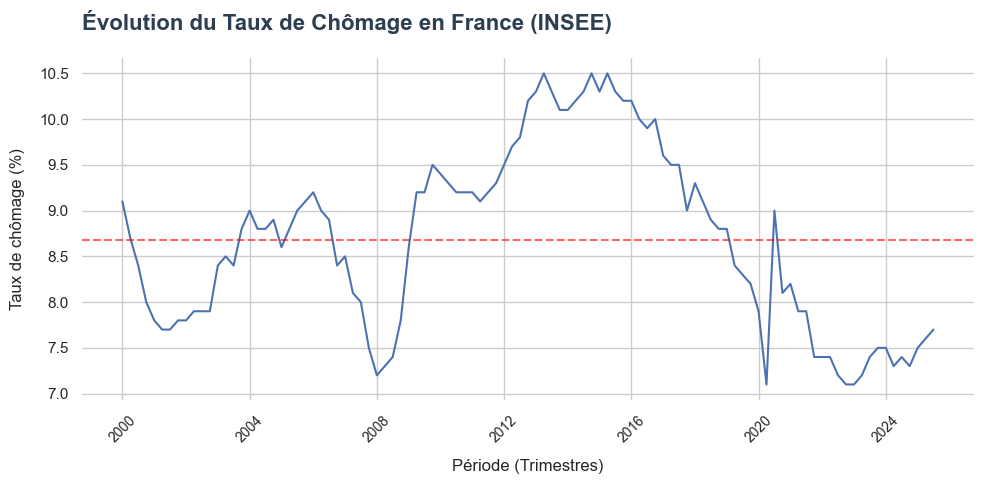

In [13]:
# 1. Configuration du style
sns.set_theme(style="whitegrid") # Fond propre avec grille discrète
plt.figure(figsize=(10, 5))

plt.title("Évolution du Taux de Chômage en France (INSEE)", 
          fontsize=16, fontweight='bold', pad=20, loc='left', color='#2c3e50')

plt.xlabel("Période (Trimestres)", fontsize=12, labelpad=10)
plt.ylabel("Taux de chômage (%)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='center', fontsize=10)

sns.despine(left=True, bottom=True)
sns.lineplot(x="date", y="taux_chomage_total_insee", data=df, estimator=np.mean)
mean_val = df['taux_chomage_total_insee'].mean()
plt.axhline(mean_val, color='red', linestyle='--', alpha=0.6, label=f"Moyenne : {mean_val:.1f}%")
plt.tight_layout()
plt.show()

### Evolution du Taux de Chômage en France (OCDE)

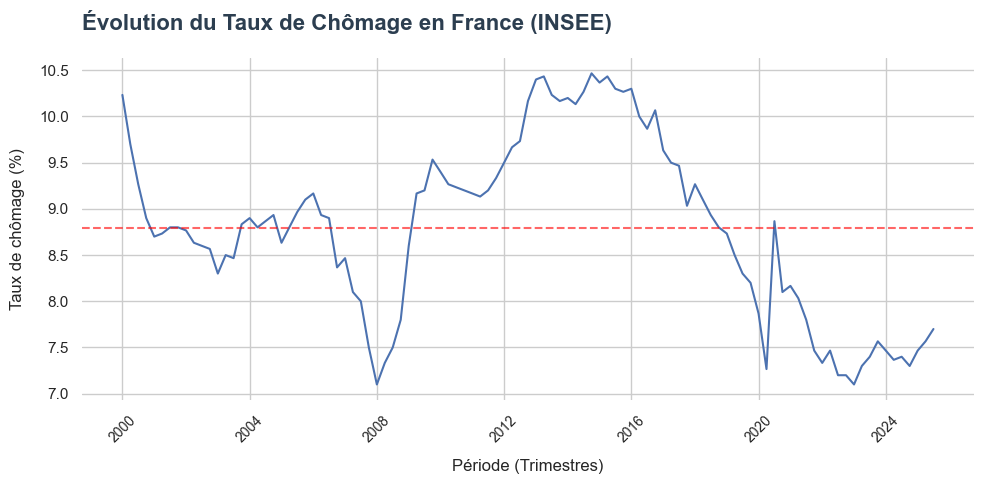

In [14]:
# 1. Configuration du style
sns.set_theme(style="whitegrid") # Fond propre avec grille discrète
plt.figure(figsize=(10, 5))

plt.title("Évolution du Taux de Chômage en France (INSEE)", 
          fontsize=16, fontweight='bold', pad=20, loc='left', color='#2c3e50')

plt.xlabel("Période (Trimestres)", fontsize=12, labelpad=10)
plt.ylabel("Taux de chômage (%)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='center', fontsize=10)

sns.despine(left=True, bottom=True)
sns.lineplot(x="date", y="taux_chomage_ocde", data=df, estimator=np.mean)
mean_val = df['taux_chomage_ocde'].mean()
plt.axhline(mean_val, color='red', linestyle='--', alpha=0.6, label=f"Moyenne : {mean_val:.1f}%")
plt.tight_layout()
plt.show()

Commentaire : OCDE et INSEE sont alignés. 

## Loi d'Okun - Relation entre Croissance du PIB et Variation du Chômage (France 2000 - 2025)

Corrélation calculée : 0.5092


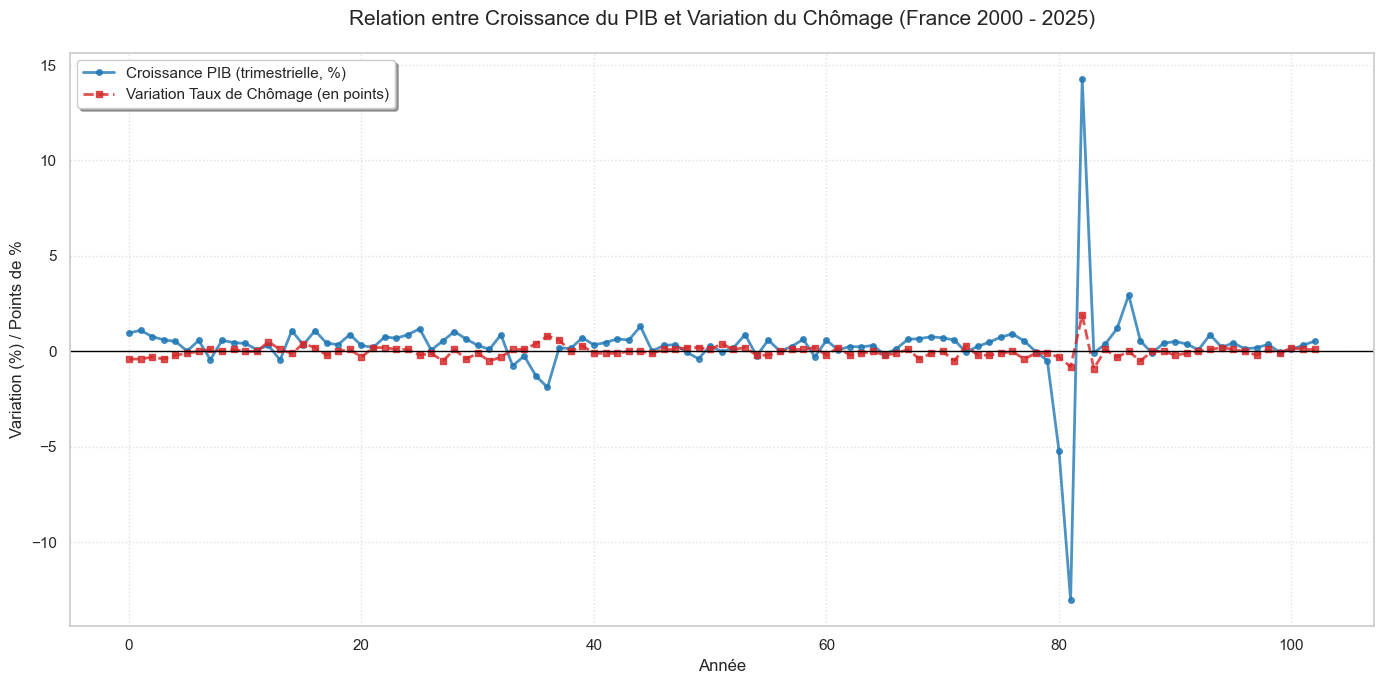

In [15]:
# 1. Préparation des données (on utilise le dataset df_q généré précédemment)
# Conversion de la croissance du PIB en pourcentage pour la lisibilité
#pib_growth_pct = df_q['pib_qoq'] * 100
pib_growth_pct = df['pib_logdiff'] * 100
var_chomage = df['taux_chomage_total_insee_diff']

# 2. Création du graphique
plt.figure(figsize=(14, 7))

# Tracé de la croissance du PIB
plt.plot(df.index, pib_growth_pct, label='Croissance PIB (trimestrielle, %)', 
         color='#1f77b4', linewidth=2, marker='o', markersize=4, alpha=0.8)

# Tracé de la variation du chômage
plt.plot(df.index, var_chomage, label='Variation Taux de Chômage (en points)', 
         color='#d62728', linestyle='--', linewidth=2, marker='s', markersize=4, alpha=0.8)

# Ajout d'une ligne horizontale à 0 (équilibre)
plt.axhline(0, color='black', linewidth=1, linestyle='-')

# 3. Personnalisation esthétique
plt.title('Relation entre Croissance du PIB et Variation du Chômage (France 2000 - 2025)', fontsize=15, pad=20)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Variation (%) / Points de %', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle=':', alpha=0.6)

# Optimisation de l'espace
plt.tight_layout()

# 4. Sauvegarde
plt.savefig('correlation_pib_chomage.png', dpi=300)

# Affichage de la corrélation calculée
correlation = pib_growth_pct.corr(var_chomage)
print(f"Corrélation calculée : {correlation:.4f}")

Analyse du graphique :

    Loi d'Okun inversée par les crises : En temps normal, une forte croissance (PIB > 0) entraîne une baisse du chômage (Variation < 0).

    Le choc COVID (2020-2021) : On observe des mouvements extrêmes. La chute brutale du PIB en 2020 n'a pas provoqué une explosion immédiate du chômage grâce aux mesures de chômage partiel. À l'inverse, le "rebond" technique de 2021 montre une corrélation positive atypique (0.53 sur l'ensemble de la période), car les indicateurs de chômage ont repris leurs niveaux normaux en même temps que l'activité.

    Signaux récents (2024-2025) : Les deux courbes se stabilisent autour de zéro, illustrant une phase de croissance molle et un chômage qui stagne ou remonte légèrement.

## Courbe de Phillips

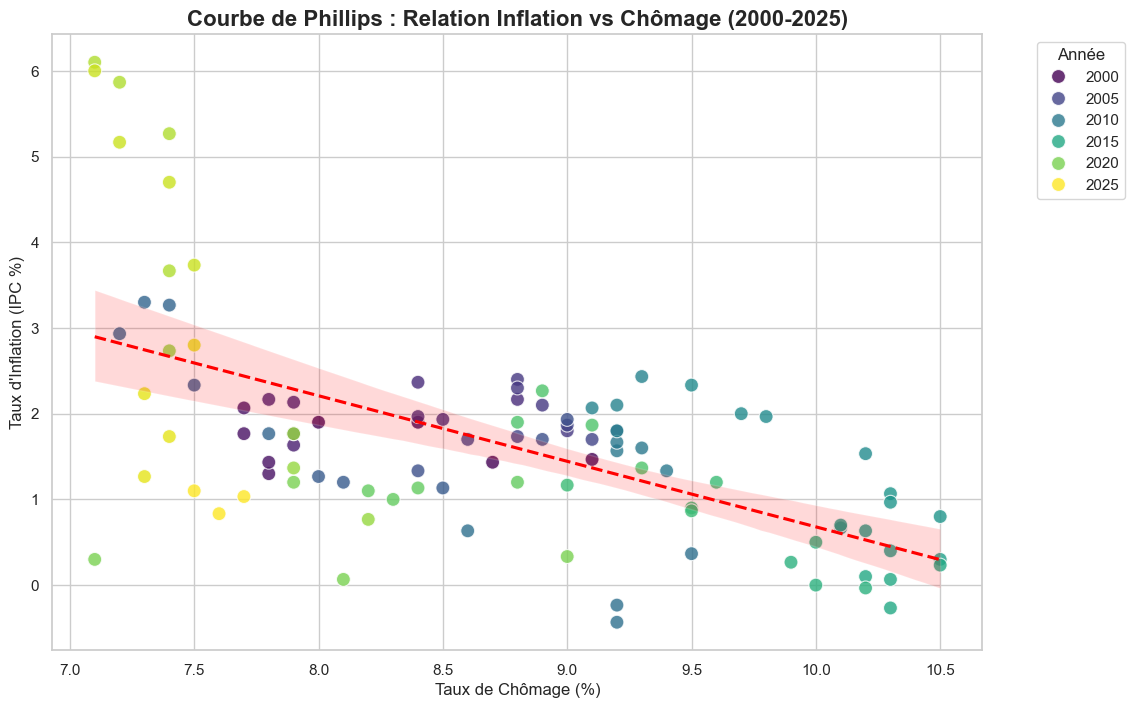

In [16]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Graphique de dispersion avec couleur selon l'année
scatter = sns.scatterplot(
    data=df, 
    x='taux_chomage_total_insee', 
    y='ipc', 
    hue=df['date'].dt.year, 
    palette='viridis', 
    s=100, 
    alpha=0.8
)

# Ajout de la droite de régression pour visualiser la "Courbe"
sns.regplot(
    data=df, 
    x='taux_chomage_total_insee', 
    y='ipc', 
    scatter=False, 
    color='red', 
    line_kws={"linestyle": "--", "label": "Tendance théorique"}
)

plt.title("Courbe de Phillips : Relation Inflation vs Chômage (2000-2025)", fontsize=16, fontweight='bold')
plt.xlabel("Taux de Chômage (%)")
plt.ylabel("Taux d'Inflation (IPC %)")
plt.legend(title="Année", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

1. Interprétation du graphique

    La relation inverse (Pente négative) : Avec une corrélation de −0,60, vos données confirment la théorie. Globalement, quand le chômage est élevé (à droite de l'axe X), l'inflation a tendance à être basse.

    Les couleurs (Évolution temporelle) :

        Les points violets/bleus (années 2000-2010) sont plutôt regroupés vers le centre.

        Les points verts/jaunes (années 2020-2025) montrent des situations extrêmes : on voit nettement le choc de 2022-2023 avec une inflation très haute et un chômage historiquement bas (en haut à gauche).
        
        
Argument Mathématique : La stationnarité et la corrélation

La corrélation de −0,60 est significative. Cela signifie que l'inflation (ipc) est un excellent prédicteur pour ton modèle de chômage. Si ton modèle de Machine Learning "connaît" l'inflation, il a déjà une très bonne idée du niveau de chômage probable.
Argument Métier : L'arbitrage Inflation / Chômage

    La logique économique : Quand l'économie est en "surchauffe" (chômage bas), les salaires ont tendance à monter car la main-d'œuvre est rare. Cette hausse des salaires se répercute sur les prix : c'est l'inflation.

    La limite actuelle (2021-2025) : Tu remarqueras que les points récents s'écartent un peu de la droite rouge (la tendance historique). C'est ce que les économistes appellent un "choc d'offre" (énergie, matières premières) : l'inflation est montée non pas parce que le chômage était bas, mais à cause de facteurs externes (guerre, supply chain).
    

# Matrice de corrélation

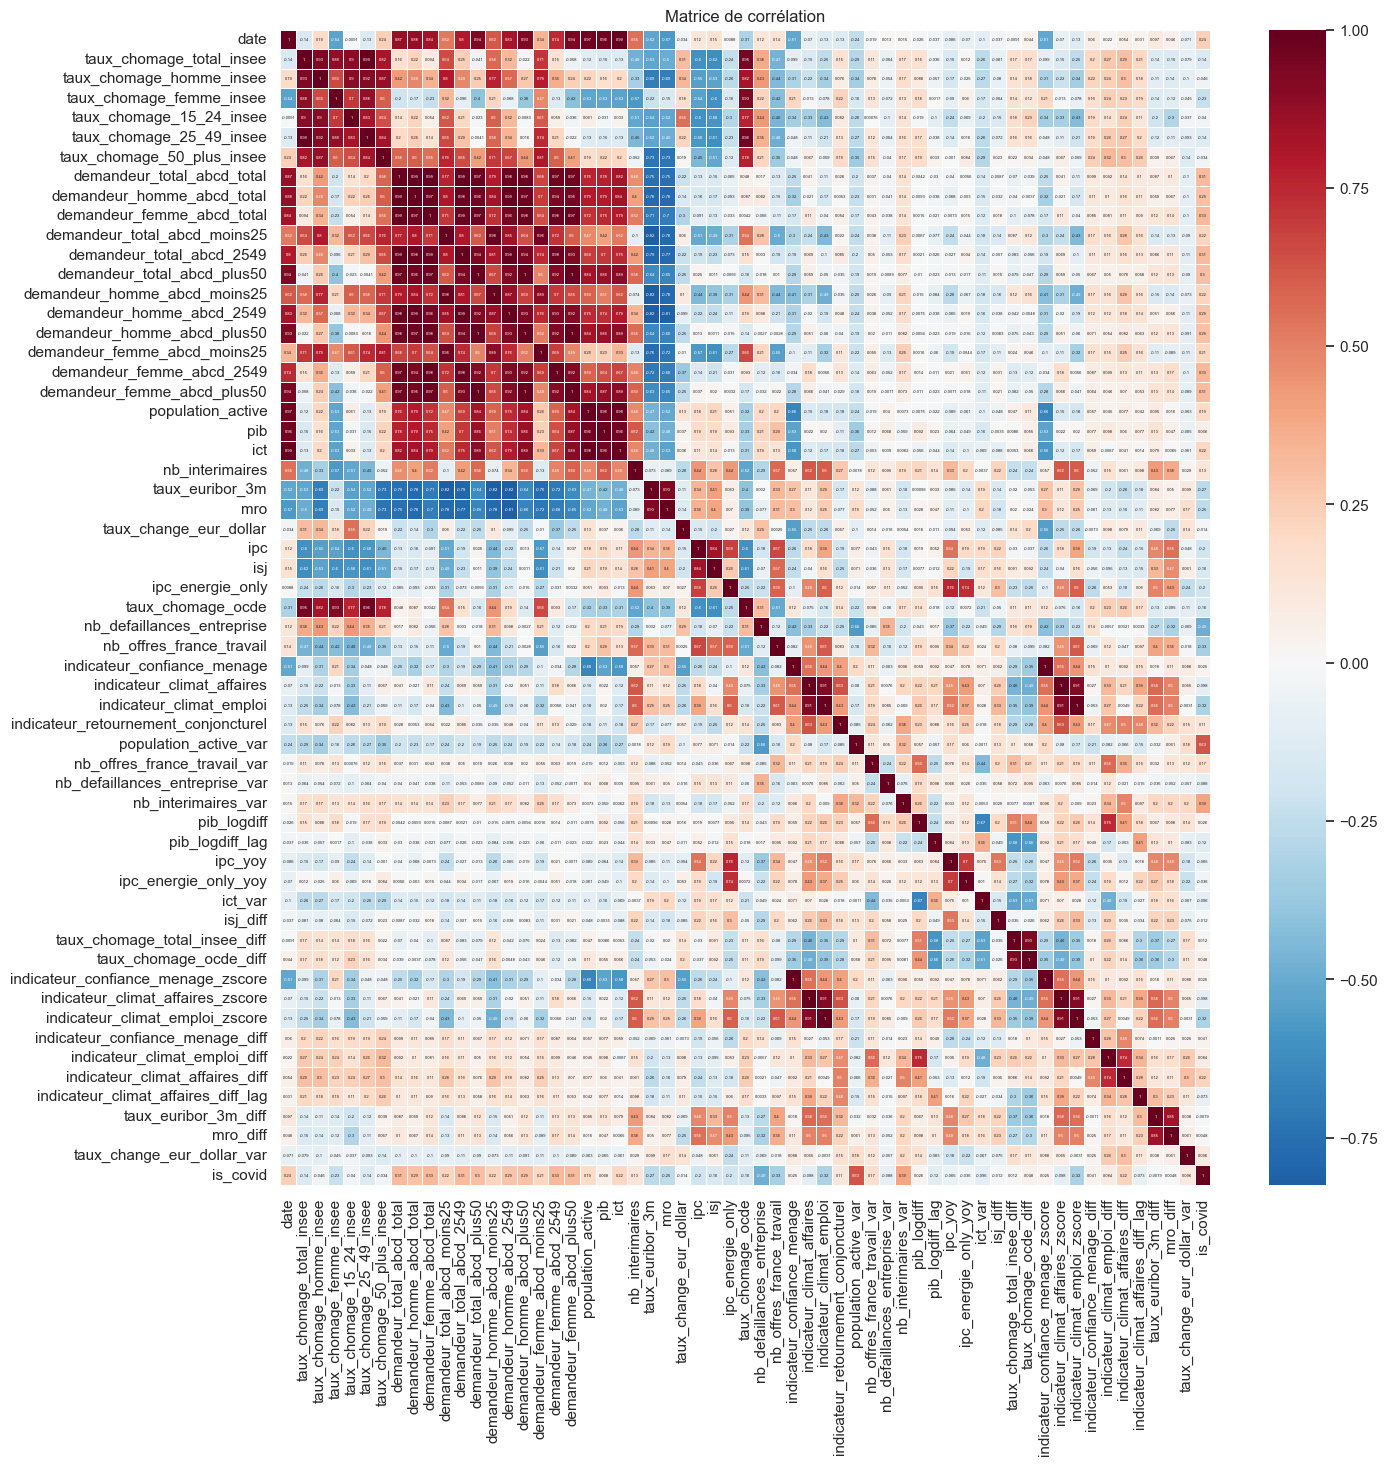

In [17]:
plt.figure(figsize=(15, 15))
df_corr = df.corr()

ax = sns.heatmap(df_corr, annot=True, cmap='RdBu_r', center=0, linewidths=0.5,annot_kws={'size': 3})
ax.figure.axes[-1].yaxis.label.set_size(10)
plt.title('Matrice de corrélation')
plt.show()



In [18]:
df_corr_chomage_insee = df.corr()['taux_chomage_total_insee']
print(df_corr_chomage_insee)

date                                   -0.141511
taux_chomage_total_insee                1.000000
taux_chomage_homme_insee                0.931717
taux_chomage_femme_insee                0.884236
taux_chomage_15_24_insee                0.895139
taux_chomage_25_49_insee                0.985755
taux_chomage_50_plus_insee              0.819563
demandeur_total_abcd_total              0.159973
demandeur_homme_abcd_total              0.216569
demandeur_femme_abcd_total              0.094437
demandeur_total_abcd_moins25            0.644496
demandeur_total_abcd_2549               0.248556
demandeur_total_abcd_plus50            -0.041106
demandeur_homme_abcd_moins25            0.576233
demandeur_homme_abcd_2549               0.317529
demandeur_homme_abcd_plus50            -0.022023
demandeur_femme_abcd_moins25            0.708352
demandeur_femme_abcd_2549               0.153293
demandeur_femme_abcd_plus50            -0.058347
population_active                      -0.116343
pib                 

In [19]:
# Filtrage des corrélations positives supérieures à 0,2 OU des corrélations négatives inférieures à -0,2
print(df_corr_chomage_insee[(df_corr_chomage_insee > 0.2) | (df_corr_chomage_insee < -0.2)])

taux_chomage_total_insee               1.000000
taux_chomage_homme_insee               0.931717
taux_chomage_femme_insee               0.884236
taux_chomage_15_24_insee               0.895139
taux_chomage_25_49_insee               0.985755
taux_chomage_50_plus_insee             0.819563
demandeur_homme_abcd_total             0.216569
demandeur_total_abcd_moins25           0.644496
demandeur_total_abcd_2549              0.248556
demandeur_homme_abcd_moins25           0.576233
demandeur_homme_abcd_2549              0.317529
demandeur_femme_abcd_moins25           0.708352
nb_interimaires                       -0.479583
taux_euribor_3m                       -0.531130
mro                                   -0.495278
taux_change_eur_dollar                 0.305948
ipc                                   -0.596794
isj                                   -0.619890
ipc_energie_only                      -0.236586
taux_chomage_ocde                      0.952564
nb_defaillances_entreprise             0

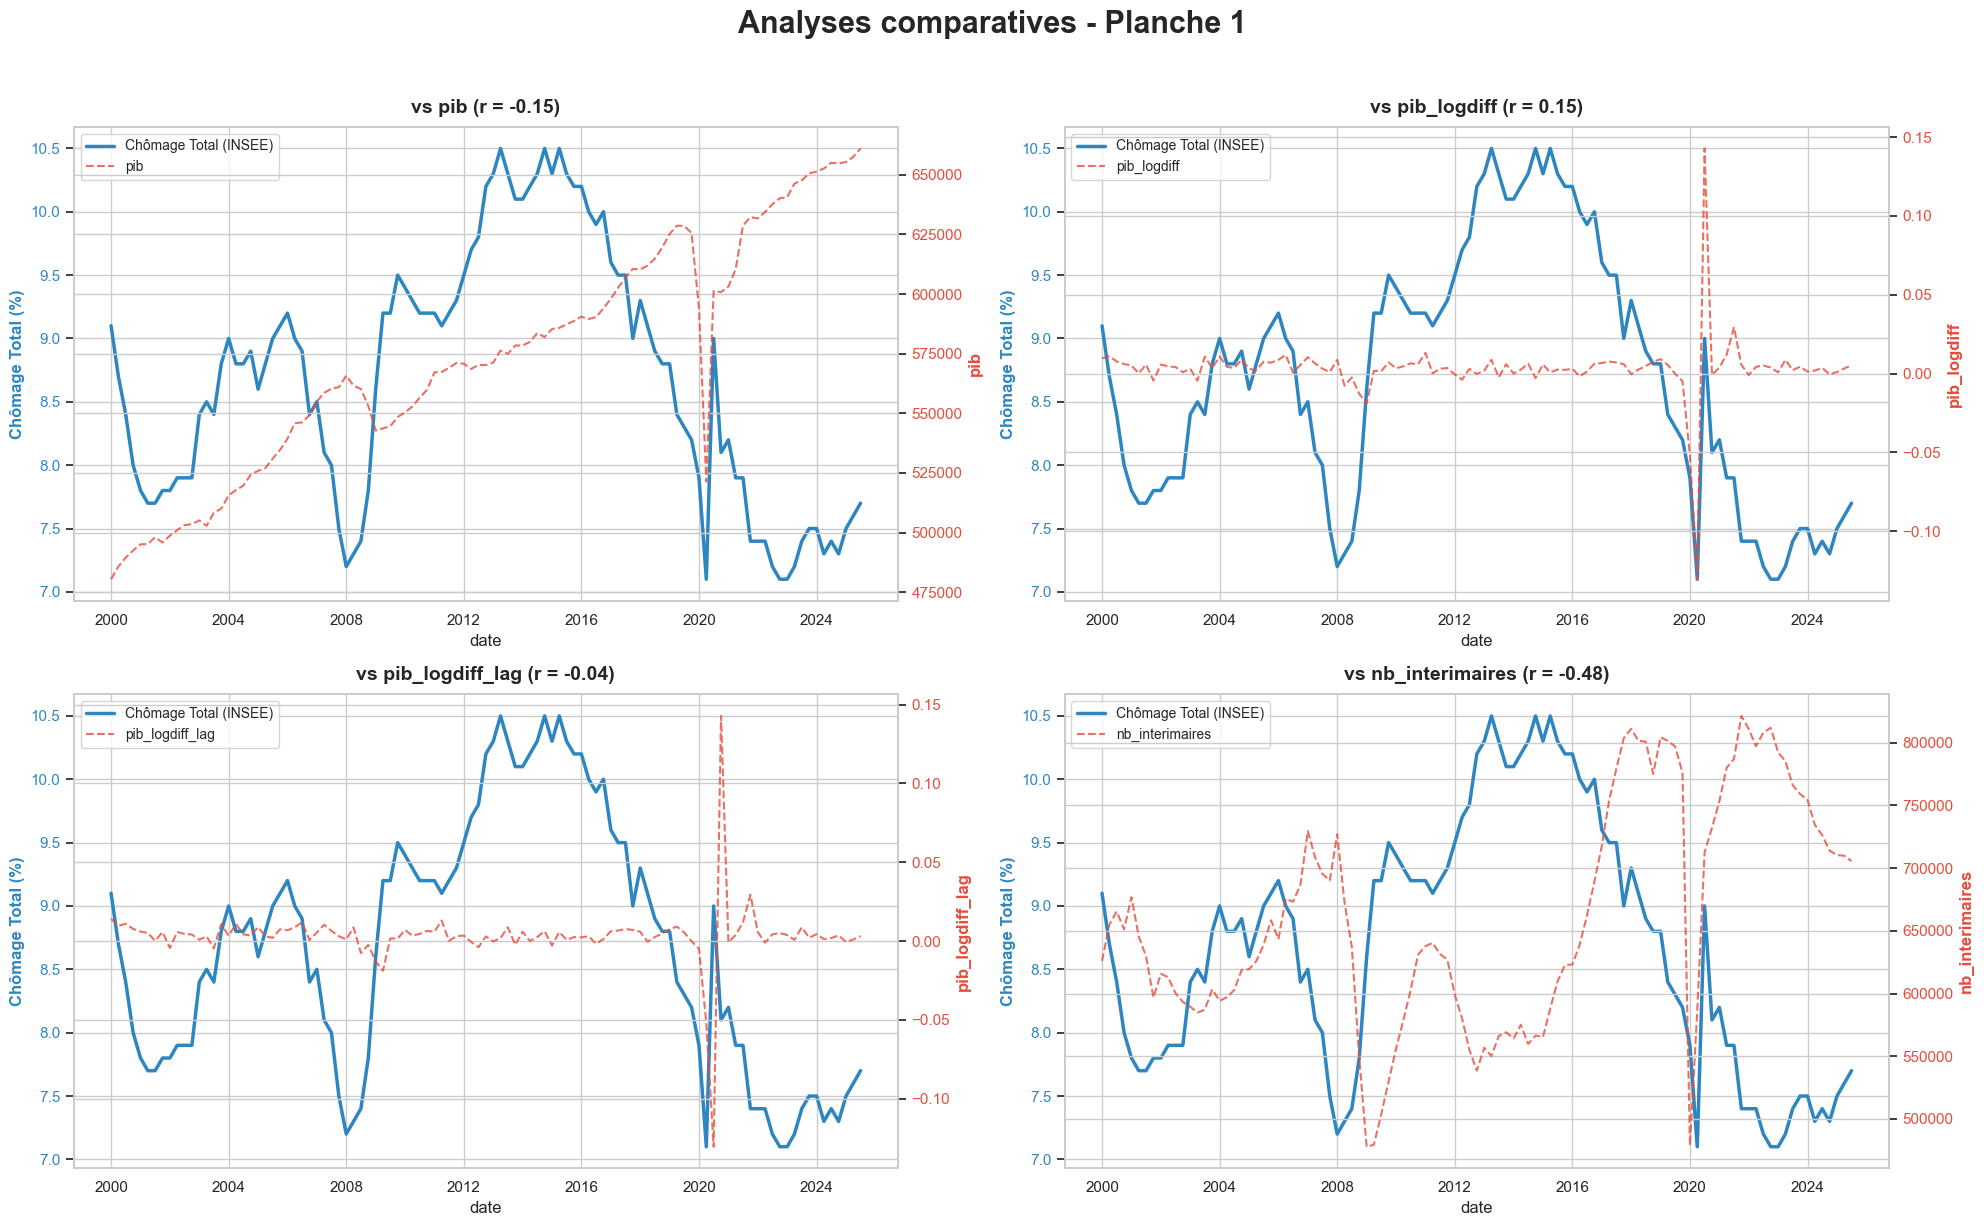

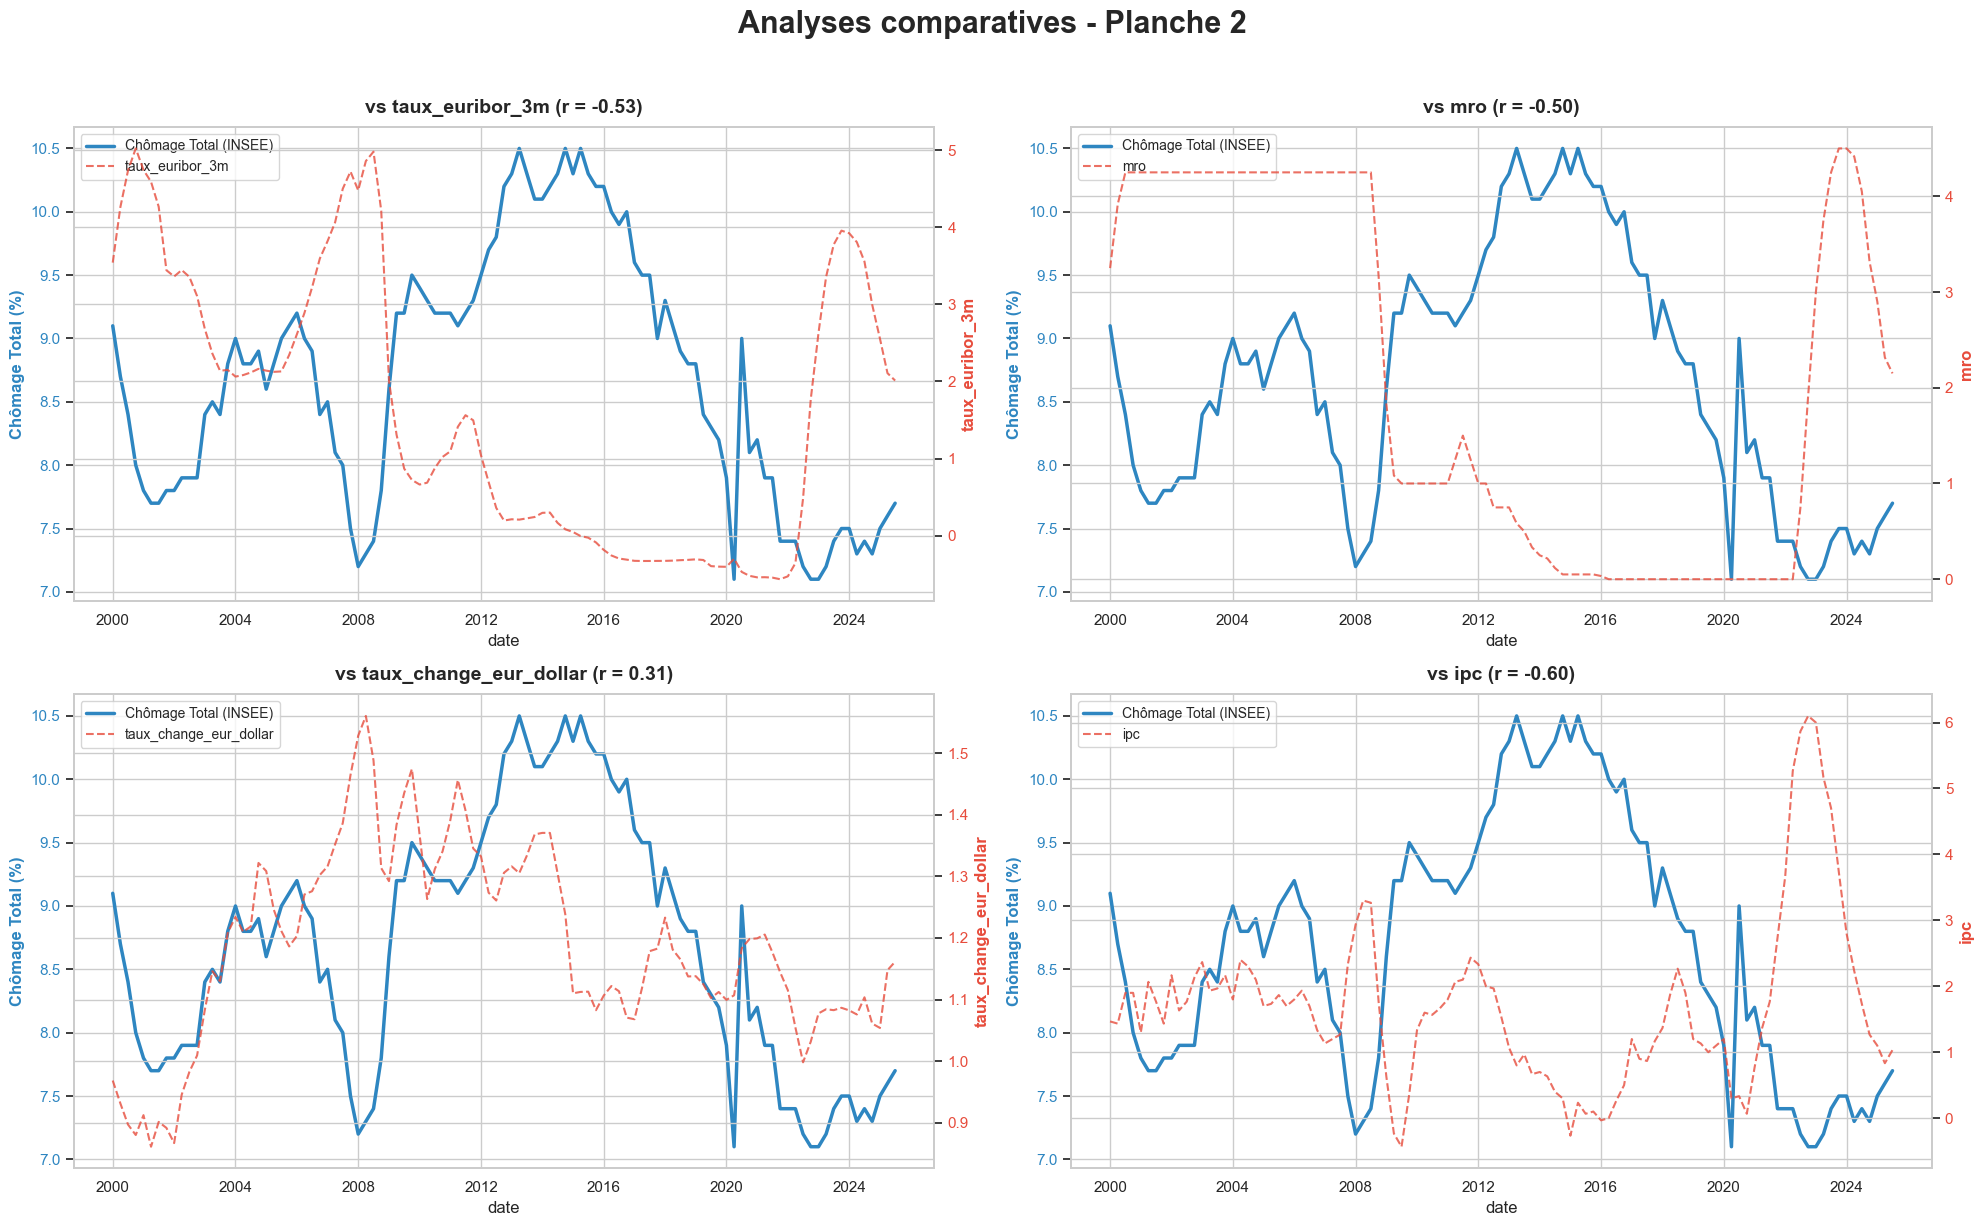

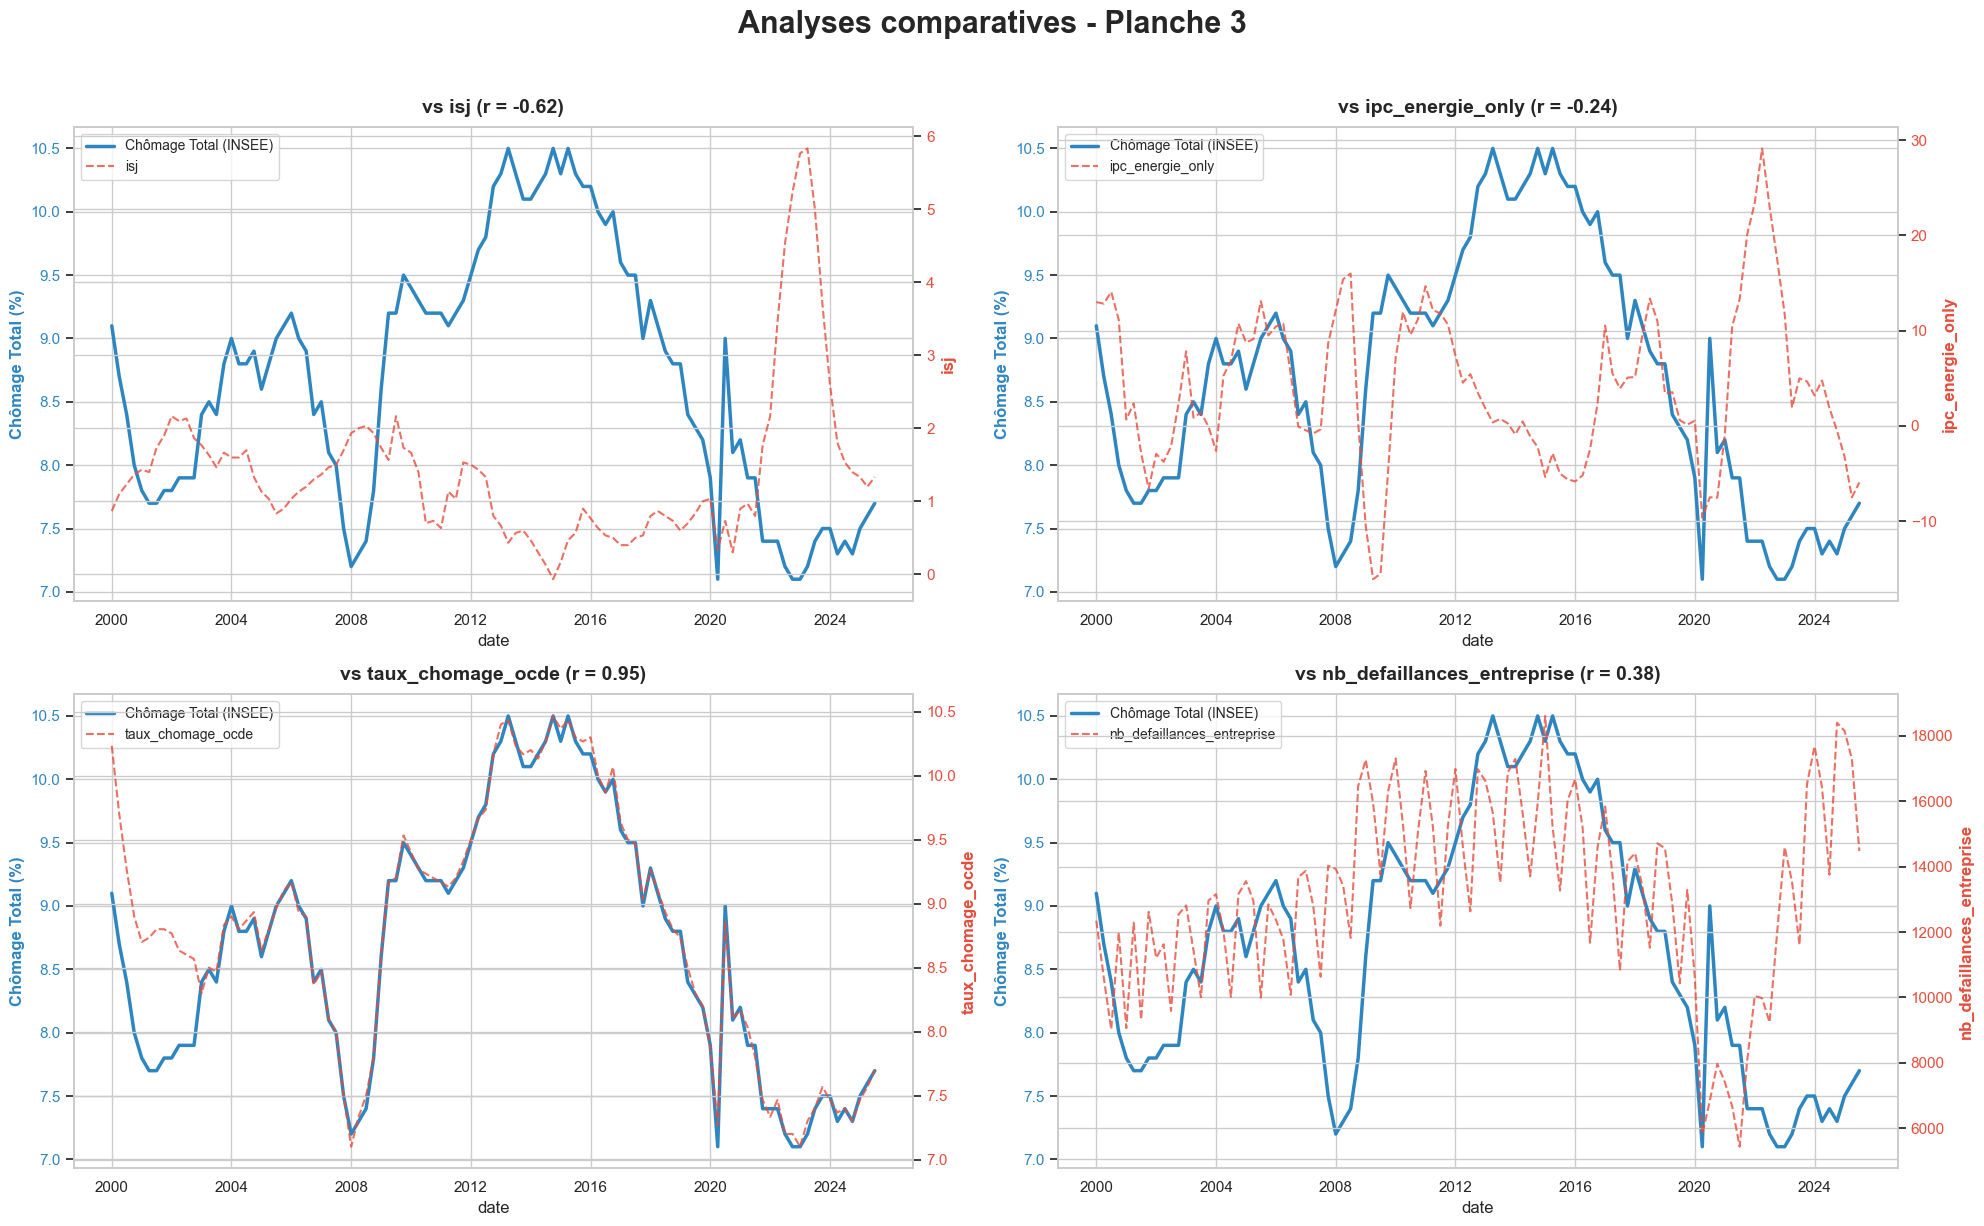

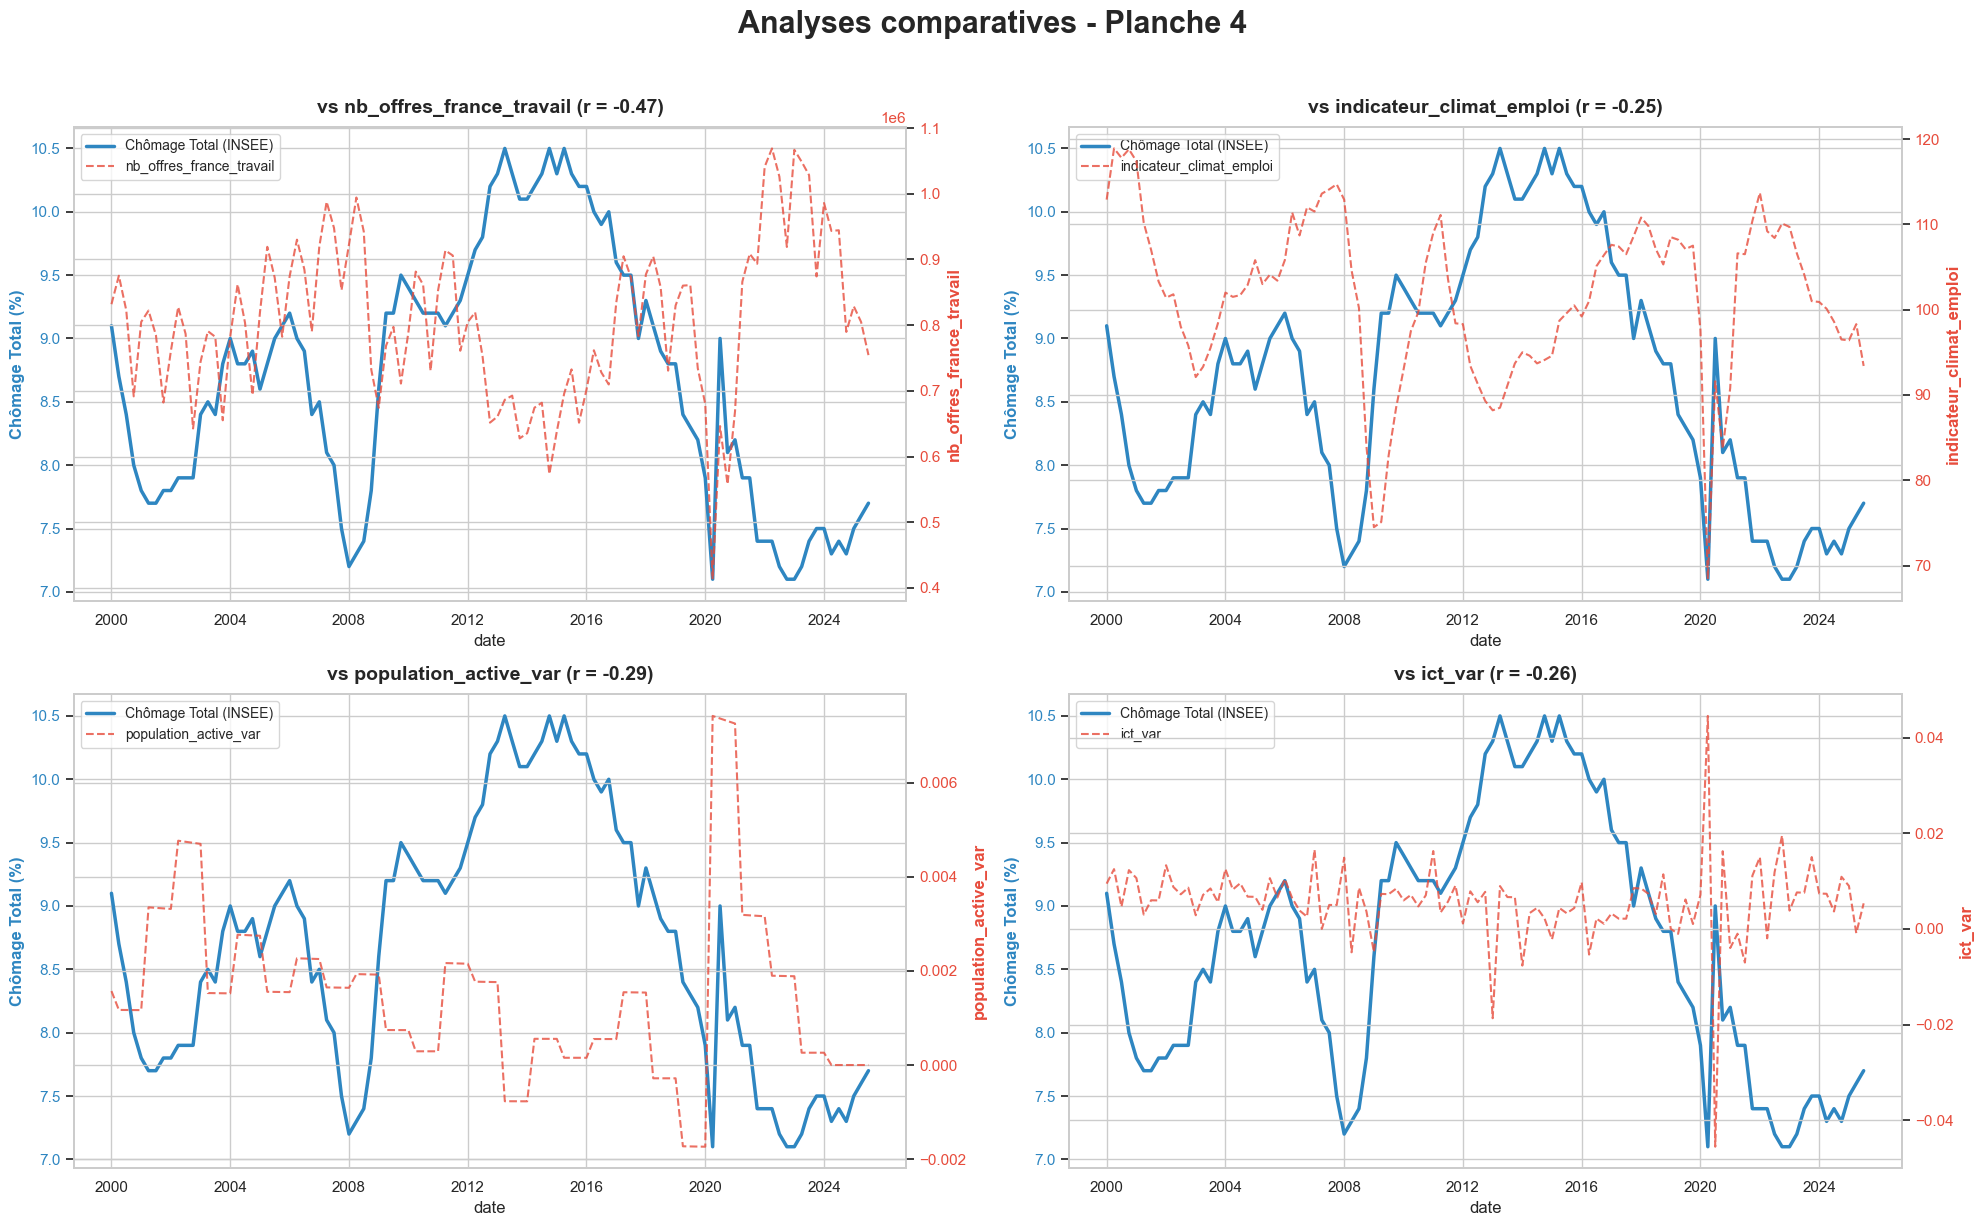

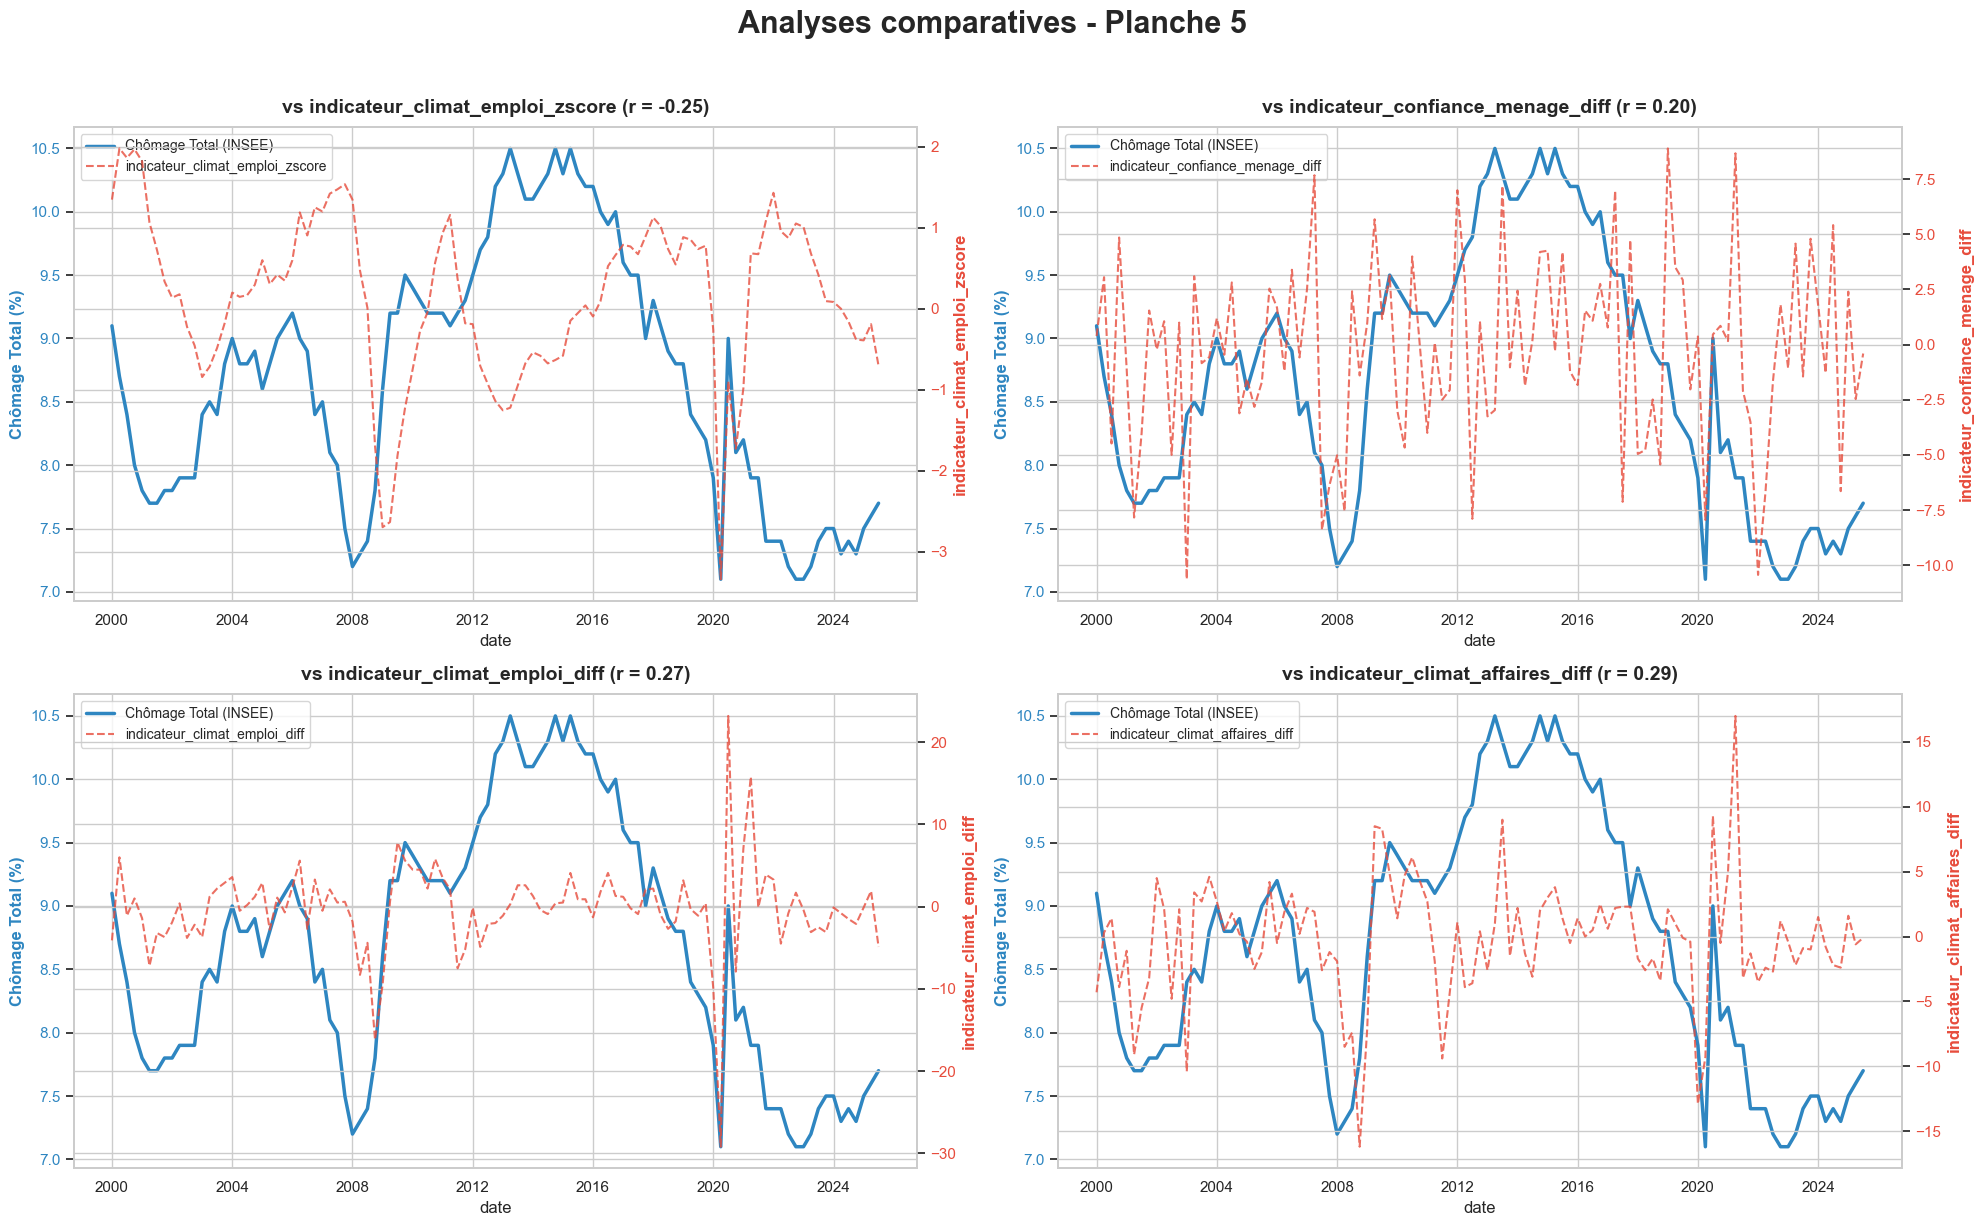

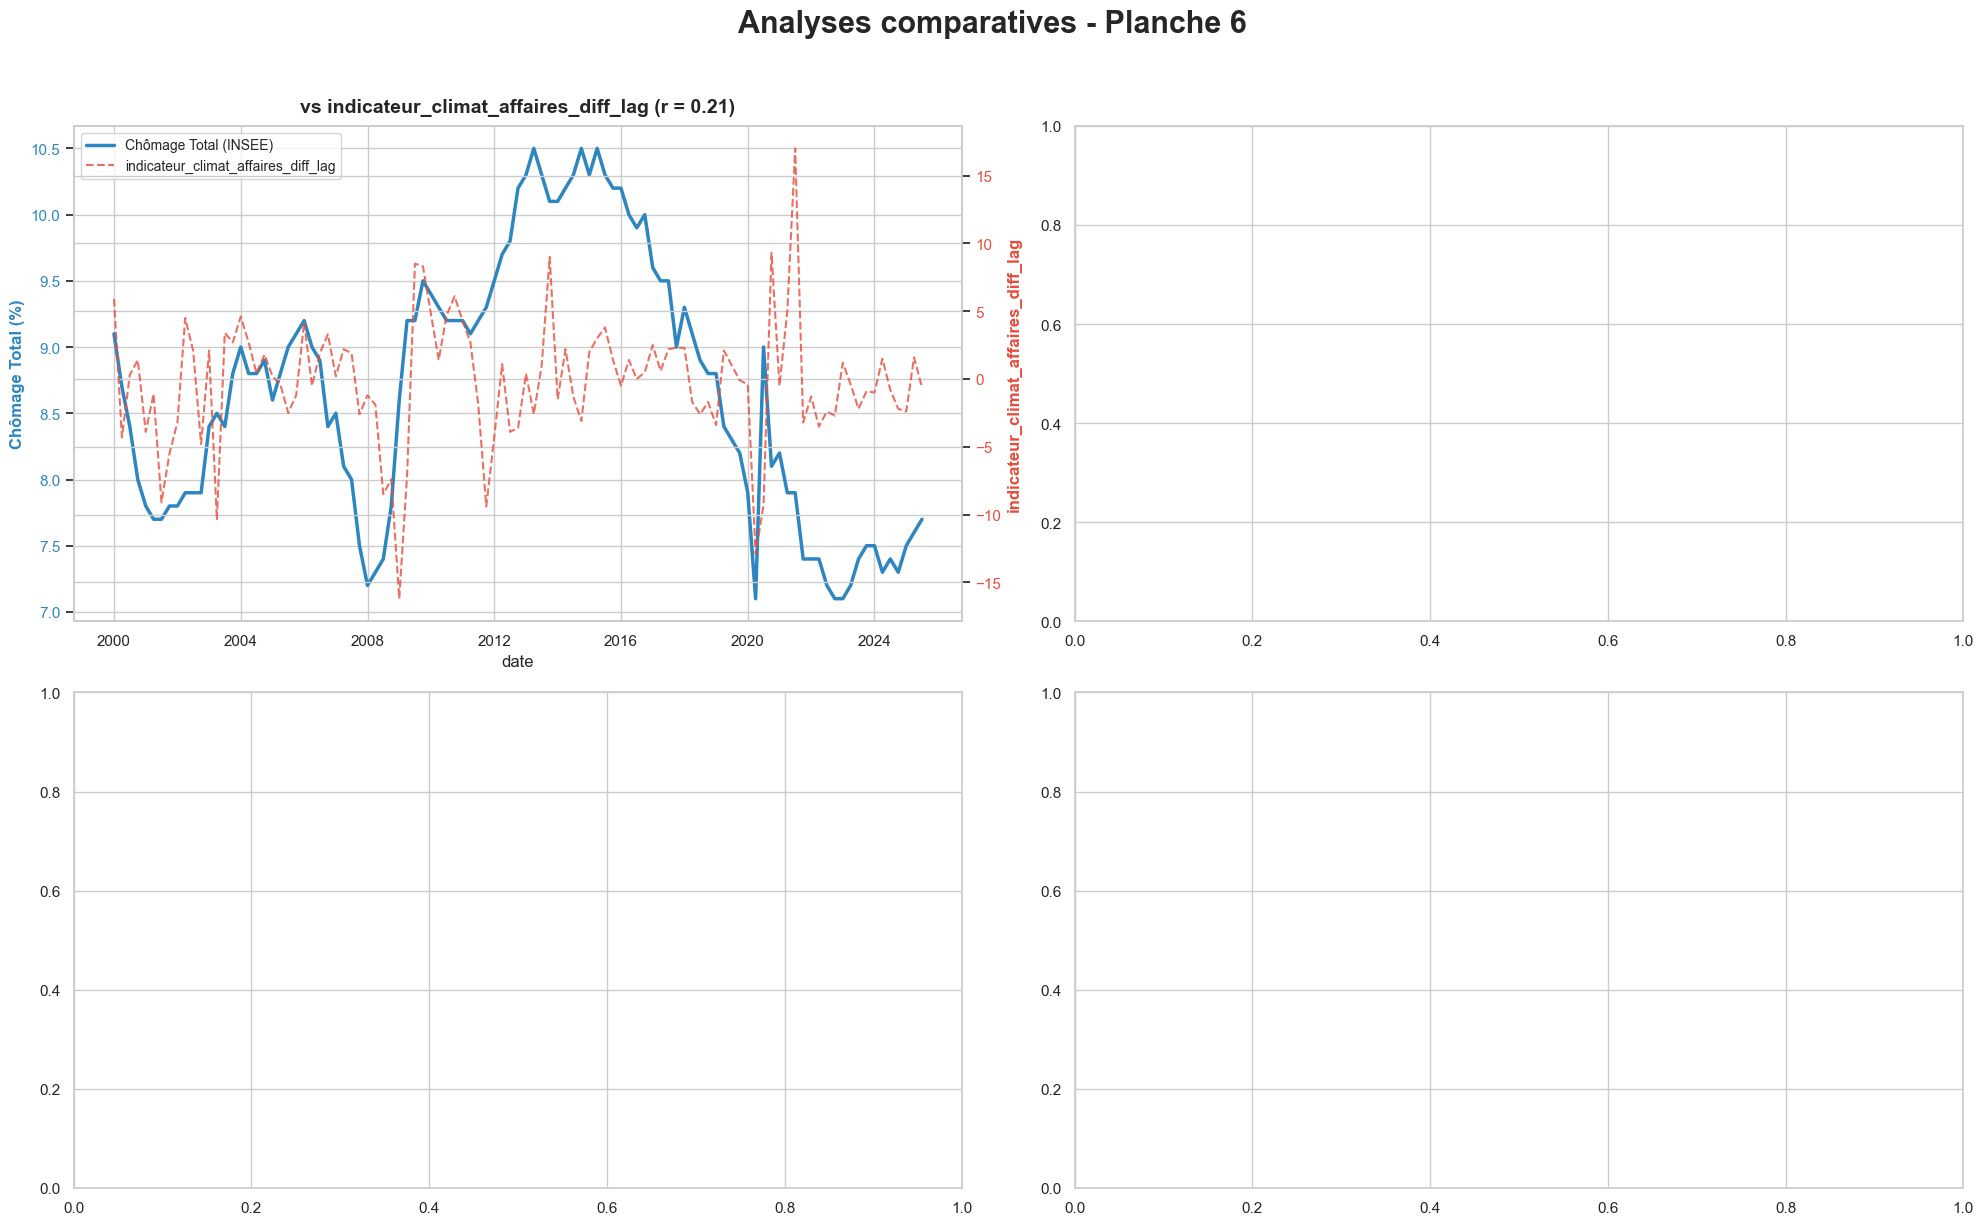

In [20]:
# 3. Liste des colonnes à comparer (basée sur ton filtre > 0.2 ou < -0.2)
cols_to_compare = [
    'pib',
    'pib_logdiff',
    'pib_logdiff_lag',
    'nb_interimaires', 
    'taux_euribor_3m', 
    'mro', 
    'taux_change_eur_dollar', 
    'ipc', 
    'isj', 
    'ipc_energie_only', 
    'taux_chomage_ocde', 
    'nb_defaillances_entreprise', 
    'nb_offres_france_travail', 
    'indicateur_climat_emploi', 
    'population_active_var', 
    'ict_var', 
    'indicateur_climat_emploi_zscore', 
    'indicateur_confiance_menage_diff', 
    'indicateur_climat_emploi_diff', 
    'indicateur_climat_affaires_diff', 
    'indicateur_climat_affaires_diff_lag'
]

target = "taux_chomage_total_insee"
sns.set_theme(style="whitegrid")
color_target = '#2E86C1' # Bleu
color_feature = '#E74C3C' # Rouge

# 4. Génération des graphiques par groupes de 4
for i in range(0, len(cols_to_compare), 4):
    subset = [c for c in cols_to_compare[i:i+4] if c in df.columns]
    if not subset: continue
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    
    for j, col in enumerate(subset):
        ax1 = axes[j]
        # Récupération du taux de corrélation
        corr_val = df_corr_chomage_insee[col]
        
        # Courbe 1 : Chômage (Axe Gauche)
        sns.lineplot(data=df, x='date', y=target, ax=ax1, color=color_target, 
                     label='Chômage Total (INSEE)', linewidth=2.5)
        ax1.set_ylabel('Chômage Total (%)', color=color_target, fontweight='bold')
        ax1.tick_params(axis='y', labelcolor=color_target)
        
        # Courbe 2 : Variable comparée (Axe Droit)
        ax2 = ax1.twinx()
        sns.lineplot(data=df, x='date', y=col, ax=ax2, color=color_feature, 
                     label=col, linestyle='--', alpha=0.8, linewidth=1.5)
        ax2.set_ylabel(col, color=color_feature, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=color_feature)
        
        # TITRE : Ajout du nom de la colonne et du coefficient de corrélation
        ax1.set_title(f"vs {col} (r = {corr_val:.2f})", fontsize=14, fontweight='bold', pad=10)
        
        # Gestion des légendes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize='small')
        if ax2.get_legend(): ax2.get_legend().remove()

    plt.suptitle(f"Analyses comparatives - Planche {i//4 + 1}", 
                 fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show() # Remplace plt.close() par plt.show()